In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import wandb

/Users/triptibhardwaj/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # maps [0,1] -> [-1,1]
])

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_full = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

full_dataset = torch.utils.data.ConcatDataset([full_train_dataset, test_dataset_full])

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:11<00:00, 2.25MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 176kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.22MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.57MB/s]

Train: 56000
Val: 7000
Test: 7000


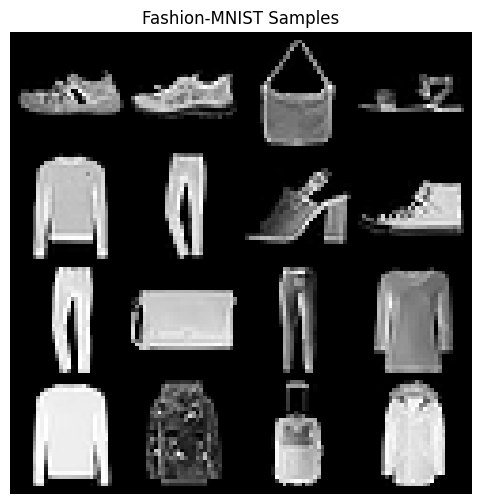

In [4]:
def denormalize(img):
    return img * 0.5 + 0.5

images, labels = next(iter(train_loader))
grid = make_grid(denormalize(images[:16]), nrow=4)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Fashion-MNIST Samples")
plt.show()

In [5]:
def get_noise(batch_size, latent_dim, device):
    return torch.randn(batch_size, latent_dim, device=device)

In [6]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, 1, 28, 28)
    
class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

In [7]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.ReLU(True)
        )
        
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 14 -> 28
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 7, 7)
        x = self.deconv(x)
        return x

In [8]:
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.model(x)

In [9]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [10]:
bce_loss = nn.BCEWithLogitsLoss()
mse_loss = nn.MSELoss()

def discriminator_bce_loss(real_logits, fake_logits):
    real_labels = torch.ones_like(real_logits)
    fake_labels = torch.zeros_like(fake_logits)
    
    real_loss = bce_loss(real_logits, real_labels)
    fake_loss = bce_loss(fake_logits, fake_labels)
    return real_loss + fake_loss

def generator_bce_loss(fake_logits):
    real_labels = torch.ones_like(fake_logits)
    return bce_loss(fake_logits, real_labels)

def discriminator_lsgan_loss(real_logits, fake_logits):
    real_labels = torch.ones_like(real_logits)
    fake_labels = torch.zeros_like(fake_logits)
    
    real_loss = mse_loss(real_logits, real_labels)
    fake_loss = mse_loss(fake_logits, fake_labels)
    return real_loss + fake_loss

def generator_lsgan_loss(fake_logits):
    real_labels = torch.ones_like(fake_logits)
    return mse_loss(fake_logits, real_labels)

def discriminator_wgan_loss(real_logits, fake_logits):
    return -(torch.mean(real_logits) - torch.mean(fake_logits))

def generator_wgan_loss(fake_logits):
    return -torch.mean(fake_logits)

In [11]:
def get_optimizer(params, optimizer_name="adam", lr=2e-4):
    optimizer_name = optimizer_name.lower()
    
    if optimizer_name == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        return optim.RMSprop(params, lr=lr)
    elif optimizer_name == "adam":
        return optim.Adam(params, lr=lr, betas=(0.5, 0.999))
    else:
        raise ValueError("optimizer_name must be 'sgd', 'rmsprop', or 'adam'")

In [12]:
def build_gan(model_type="vanilla", latent_dim=100):
    if model_type == "vanilla":
        G = VanillaGenerator(latent_dim=latent_dim).to(device)
        D = VanillaDiscriminator().to(device)
    elif model_type == "dcgan":
        G = DCGenerator(latent_dim=latent_dim).to(device)
        D = DCDiscriminator().to(device)
    else:
        raise ValueError("model_type must be 'vanilla' or 'dcgan'")
    
    G.apply(weights_init)
    D.apply(weights_init)
    
    return G, D

In [13]:
def train_gan(
    generator,
    discriminator,
    train_loader,
    g_optimizer,
    d_optimizer,
    latent_dim=100,
    epochs=10,
    loss_type="bce",
    model_type="vanilla",
    clip_value=0.01
):
    history = {
        "g_loss": [],
        "d_loss": []
    }
    
    fixed_noise = get_noise(16, latent_dim, device)
    generated_snapshots = []
    
    for epoch in range(epochs):
        generator.train()
        discriminator.train()
        
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        
        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            z = get_noise(batch_size, latent_dim, device)
            fake_images = generator(z).detach()
            
            d_optimizer.zero_grad()
            
            real_logits = discriminator(real_images)
            fake_logits = discriminator(fake_images)
            
            if loss_type == "bce":
                d_loss = discriminator_bce_loss(real_logits, fake_logits)
            elif loss_type == "lsgan":
                d_loss = discriminator_lsgan_loss(real_logits, fake_logits)
            elif loss_type == "wgan":
                d_loss = discriminator_wgan_loss(real_logits, fake_logits)
            else:
                raise ValueError("loss_type must be 'bce', 'lsgan', or 'wgan'")
            
            d_loss.backward()
            d_optimizer.step()
            
            if loss_type == "wgan":
                for p in discriminator.parameters():
                    p.data.clamp_(-clip_value, clip_value)
            
            z = get_noise(batch_size, latent_dim, device)
            g_optimizer.zero_grad()
            
            generated_images = generator(z)
            fake_logits = discriminator(generated_images)
            
            if loss_type == "bce":
                g_loss = generator_bce_loss(fake_logits)
            elif loss_type == "lsgan":
                g_loss = generator_lsgan_loss(fake_logits)
            elif loss_type == "wgan":
                g_loss = generator_wgan_loss(fake_logits)
            
            g_loss.backward()
            g_optimizer.step()
            
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
        
        avg_g_loss = epoch_g_loss / len(train_loader)
        avg_d_loss = epoch_d_loss / len(train_loader)
        
        history["g_loss"].append(avg_g_loss)
        history["d_loss"].append(avg_d_loss)
        
        generator.eval()
        with torch.no_grad():
            fake_samples = generator(fixed_noise).cpu()
        generated_snapshots.append(fake_samples)
        
        print(f"Epoch [{epoch+1}/{epochs}] | G Loss: {avg_g_loss:.4f} | D Loss: {avg_d_loss:.4f}")
    
    return history, generated_snapshots

In [14]:
def plot_gan_history(history, title="GAN Training History"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["g_loss"], label="Generator Loss")
    plt.plot(history["d_loss"], label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def show_generated_images(images, title="Generated Images"):
    images = denormalize(images)
    grid = make_grid(images, nrow=4)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

Epoch [1/10] | G Loss: 1.2569 | D Loss: 1.0531
Epoch [2/10] | G Loss: 1.3671 | D Loss: 1.1588
Epoch [3/10] | G Loss: 1.1793 | D Loss: 1.2299
Epoch [4/10] | G Loss: 1.0388 | D Loss: 1.2924
Epoch [5/10] | G Loss: 1.0178 | D Loss: 1.2921
Epoch [6/10] | G Loss: 1.0458 | D Loss: 1.2805
Epoch [7/10] | G Loss: 1.0592 | D Loss: 1.2761
Epoch [8/10] | G Loss: 1.0585 | D Loss: 1.2756
Epoch [9/10] | G Loss: 1.0248 | D Loss: 1.2926
Epoch [10/10] | G Loss: 0.9765 | D Loss: 1.3039


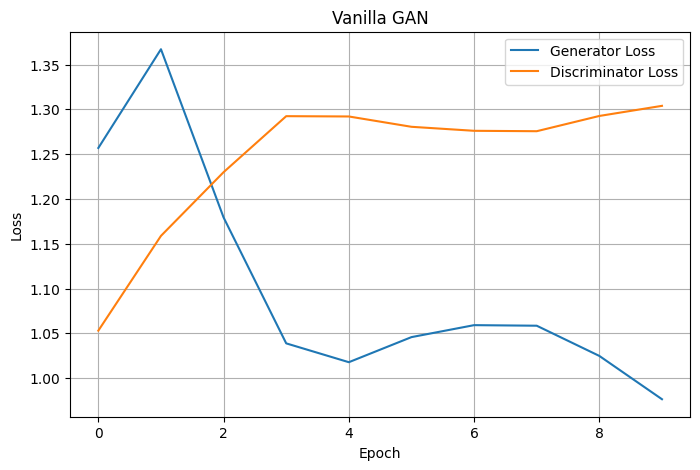

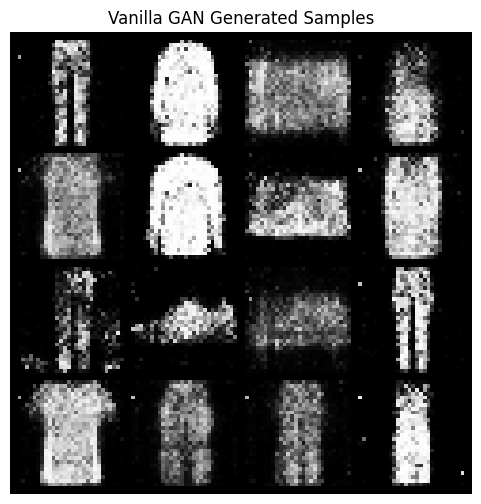

In [15]:
latent_dim = 100
model_type = "vanilla"
loss_type = "bce"
optimizer_name = "adam"
epochs = 10

G, D = build_gan(model_type=model_type, latent_dim=latent_dim)

g_optimizer = get_optimizer(G.parameters(), optimizer_name=optimizer_name, lr=2e-4)
d_optimizer = get_optimizer(D.parameters(), optimizer_name=optimizer_name, lr=2e-4)

history, snapshots = train_gan(
    generator=G,
    discriminator=D,
    train_loader=train_loader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    latent_dim=latent_dim,
    epochs=epochs,
    loss_type=loss_type,
    model_type=model_type
)

plot_gan_history(history, title="Vanilla GAN")
show_generated_images(snapshots[-1], title="Vanilla GAN Generated Samples")

Epoch [1/10] | G Loss: 1.2681 | D Loss: 1.0397
Epoch [2/10] | G Loss: 1.3663 | D Loss: 1.1525
Epoch [3/10] | G Loss: 1.1946 | D Loss: 1.2273
Epoch [4/10] | G Loss: 1.1001 | D Loss: 1.2563
Epoch [5/10] | G Loss: 1.0525 | D Loss: 1.2758
Epoch [6/10] | G Loss: 1.0903 | D Loss: 1.2627
Epoch [7/10] | G Loss: 1.0753 | D Loss: 1.2609
Epoch [8/10] | G Loss: 0.9874 | D Loss: 1.3016
Epoch [9/10] | G Loss: 0.9865 | D Loss: 1.3079
Epoch [10/10] | G Loss: 0.9854 | D Loss: 1.3058


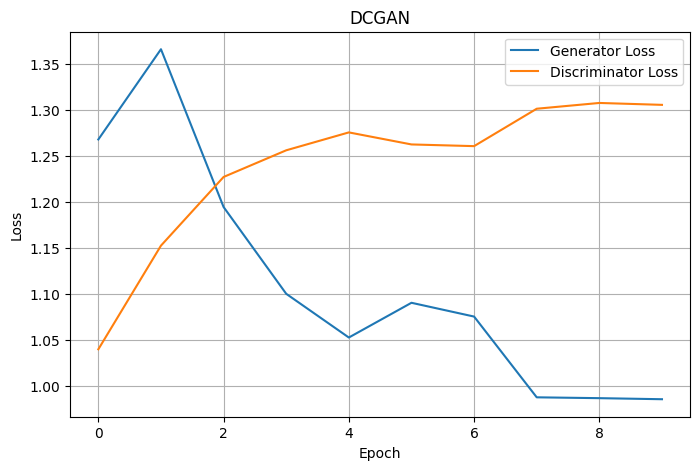

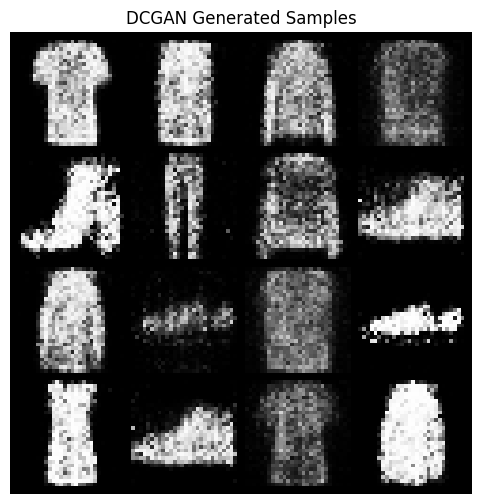

In [16]:
latent_dim = 100
l_type = "dcgan"
loss_type = "bce"
optimizer_name = "adam"
epochs = 10
    
G, D = build_gan(model_type=model_type, latent_dim=latent_dim)

g_optimizer = get_optimizer(G.parameters(), optimizer_name=optimizer_name, lr=2e-4)
d_optimizer = get_optimizer(D.parameters(), optimizer_name=optimizer_name, lr=2e-4)

history, snapshots = train_gan(
    generator=G,
    discriminator=D,
    train_loader=train_loader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    latent_dim=latent_dim,
    epochs=epochs,
    loss_type=loss_type,
    model_type=model_type
)

plot_gan_history(history, title="DCGAN")
show_generated_images(snapshots[-1], title="DCGAN Generated Samples")

In [17]:
model_types = ["vanilla", "dcgan"]
loss_types = ["bce", "lsgan", "wgan"]
optimizer_names = ["sgd", "rmsprop", "adam"]

results = []

for model_type in model_types:
    for loss_type in loss_types:
        for optimizer_name in optimizer_names:
            print(f"\n=== {model_type.upper()} | {loss_type.upper()} | {optimizer_name.upper()} ===")
            
            G, D = build_gan(model_type=model_type, latent_dim=100)
            
            g_optimizer = get_optimizer(G.parameters(), optimizer_name=optimizer_name, lr=2e-4)
            d_optimizer = get_optimizer(D.parameters(), optimizer_name=optimizer_name, lr=2e-4)
            
            history, snapshots = train_gan(
                generator=G,
                discriminator=D,
                train_loader=train_loader,
                g_optimizer=g_optimizer,
                d_optimizer=d_optimizer,
                latent_dim=100,
                epochs=5,
                loss_type=loss_type,
                model_type=model_type
            )
            
            results.append({
                "model_type": model_type,
                "loss_type": loss_type,
                "optimizer": optimizer_name,
                "final_g_loss": history["g_loss"][-1],
                "final_d_loss": history["d_loss"][-1]
            })


=== VANILLA | BCE | SGD ===
Epoch [1/5] | G Loss: 0.6950 | D Loss: 0.9959
Epoch [2/5] | G Loss: 0.6690 | D Loss: 0.8824
Epoch [3/5] | G Loss: 0.6826 | D Loss: 1.0229
Epoch [4/5] | G Loss: 0.7603 | D Loss: 0.9870
Epoch [5/5] | G Loss: 0.9816 | D Loss: 0.7985

=== VANILLA | BCE | RMSPROP ===
Epoch [1/5] | G Loss: 0.7033 | D Loss: 1.3195
Epoch [2/5] | G Loss: 0.7713 | D Loss: 1.3277
Epoch [3/5] | G Loss: 0.7790 | D Loss: 1.3396
Epoch [4/5] | G Loss: 0.7807 | D Loss: 1.3477
Epoch [5/5] | G Loss: 0.7810 | D Loss: 1.3494

=== VANILLA | BCE | ADAM ===
Epoch [1/5] | G Loss: 1.2406 | D Loss: 1.0781
Epoch [2/5] | G Loss: 1.3506 | D Loss: 1.1598
Epoch [3/5] | G Loss: 1.1358 | D Loss: 1.2541
Epoch [4/5] | G Loss: 1.0533 | D Loss: 1.2813
Epoch [5/5] | G Loss: 1.0298 | D Loss: 1.2961

=== VANILLA | LSGAN | SGD ===
Epoch [1/5] | G Loss: 0.6535 | D Loss: 0.1241
Epoch [2/5] | G Loss: 0.5932 | D Loss: 0.0866
Epoch [3/5] | G Loss: 0.5619 | D Loss: 0.1215
Epoch [4/5] | G Loss: 0.5970 | D Loss: 0.1237
Epo

In [18]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("gan_experiment_results.csv", index=False)

   model_type loss_type optimizer  final_g_loss  final_d_loss
0     vanilla       bce       sgd      0.981581      0.798542
1     vanilla       bce   rmsprop      0.781046      1.349423
2     vanilla       bce      adam      1.029794      1.296109
3     vanilla     lsgan       sgd      0.722896      0.089584
4     vanilla     lsgan   rmsprop      0.326887      0.459460
5     vanilla     lsgan      adam      0.468229      0.420017
6     vanilla      wgan       sgd     -3.593337     -0.350621
7     vanilla      wgan   rmsprop     -0.335765     -0.042148
8     vanilla      wgan      adam     -0.209107     -0.060391
9       dcgan       bce       sgd      5.792810      0.274474
10      dcgan       bce   rmsprop      0.788151      1.338822
11      dcgan       bce      adam      0.924279      1.218648
12      dcgan     lsgan       sgd      0.943655      0.091716
13      dcgan     lsgan   rmsprop      0.294482      0.543604
14      dcgan     lsgan      adam      0.379762      0.444849
15      

In [19]:
torch.save(G.state_dict(), "generator_final.pth")
torch.save(D.state_dict(), "discriminator_final.pth")

In [20]:
from huggingface_hub import create_repo, upload_file

create_repo("dl-lab9-gan", private=False, exist_ok=True)

upload_file(
    path_or_fileobj="discriminator_final.pth",
    path_in_repo="discriminator_final.pth",
    repo_id="triptibhardwaj/dl-lab9-gan"
)

upload_file(
    path_or_fileobj="generator_final.pth",
    path_in_repo="generator_final.pth",
    repo_id="triptibhardwaj/dl-lab9-gan"
)

/Users/triptibhardwaj/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing Files (1 / 1): 100%|██████████|  152kB /  152kB, 39.9kB/s  
New Data Upload: 100%|██████████|  152kB /  152kB, 39.9kB/s  
Processing Files (1 / 1): 100%|██████████| 3.20MB / 3.20MB, 42.2kB/s  
New Data Upload: 100%|██████████| 3.20MB / 3.20MB, 42.2kB/s  


CommitInfo(commit_url='https://huggingface.co/triptibhardwaj/dl-lab9-gan/commit/78d2aca2cbc26d1180cc2bcc36eb4fde08e5cf4f', commit_message='Upload generator_final.pth with huggingface_hub', commit_description='', oid='78d2aca2cbc26d1180cc2bcc36eb4fde08e5cf4f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/triptibhardwaj/dl-lab9-gan', endpoint='https://huggingface.co', repo_type='model', repo_id='triptibhardwaj/dl-lab9-gan'), pr_revision=None, pr_num=None)

In [21]:
def train_gan_wandb(generator, discriminator, train_loader, g_optimizer, d_optimizer, config):
    wandb.init(entity="triptibhardwaj_25afi04", project="fashion-mnist-gan", config=config)
    
    latent_dim = config["latent_dim"]
    epochs = config["epochs"]
    loss_type = config["loss_type"]
    clip_value = config.get("clip_value", 0.01)

    fixed_noise = torch.randn(16, latent_dim, device=device)

    for epoch in range(epochs):
        generator.train()
        discriminator.train()

        g_epoch_loss = 0.0
        d_epoch_loss = 0.0

        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z).detach()

            d_optimizer.zero_grad()

            real_logits = discriminator(real_images)
            fake_logits = discriminator(fake_images)

            if loss_type == "bce":
                real_labels = torch.ones_like(real_logits)
                fake_labels = torch.zeros_like(fake_logits)

                d_real_loss = nn.BCEWithLogitsLoss()(real_logits, real_labels)
                d_fake_loss = nn.BCEWithLogitsLoss()(fake_logits, fake_labels)
                d_loss = d_real_loss + d_fake_loss

            elif loss_type == "lsgan":
                real_labels = torch.ones_like(real_logits)
                fake_labels = torch.zeros_like(fake_logits)

                d_real_loss = nn.MSELoss()(real_logits, real_labels)
                d_fake_loss = nn.MSELoss()(fake_logits, fake_labels)
                d_loss = d_real_loss + d_fake_loss

            elif loss_type == "wgan":
                d_loss = -(torch.mean(real_logits) - torch.mean(fake_logits))

            d_loss.backward()
            d_optimizer.step()

            if loss_type == "wgan":
                for p in discriminator.parameters():
                    p.data.clamp_(-clip_value, clip_value)

            z = torch.randn(batch_size, latent_dim, device=device)

            g_optimizer.zero_grad()
            generated_images = generator(z)
            fake_logits = discriminator(generated_images)

            if loss_type == "bce":
                real_labels = torch.ones_like(fake_logits)
                g_loss = nn.BCEWithLogitsLoss()(fake_logits, real_labels)

            elif loss_type == "lsgan":
                real_labels = torch.ones_like(fake_logits)
                g_loss = nn.MSELoss()(fake_logits, real_labels)

            elif loss_type == "wgan":
                g_loss = -torch.mean(fake_logits)

            g_loss.backward()
            g_optimizer.step()

            g_epoch_loss += g_loss.item()
            d_epoch_loss += d_loss.item()

        g_epoch_loss /= len(train_loader)
        d_epoch_loss /= len(train_loader)

        wandb.log({
            "epoch": epoch + 1,
            "generator_loss": g_epoch_loss,
            "discriminator_loss": d_epoch_loss,
            "g_lr": g_optimizer.param_groups[0]["lr"],
            "d_lr": d_optimizer.param_groups[0]["lr"]
        })

        if epoch % 2 == 0:
            generator.eval()
            with torch.no_grad():
                sample_images = generator(fixed_noise).cpu()

            sample_images = (sample_images + 1) / 2.0

            wandb.log({
                "generated_samples": [
                    wandb.Image(sample_images[i].squeeze().numpy())
                    for i in range(min(4, sample_images.size(0)))
                ]
            })

        print(f"Epoch {epoch+1}: G_loss={g_epoch_loss:.4f}, D_loss={d_epoch_loss:.4f}")

    wandb.finish()

In [22]:
def build_gan_models(model_type="vanilla", latent_dim=100):
    if model_type == "vanilla":
        generator = VanillaGenerator(latent_dim=latent_dim).to(device)
        discriminator = VanillaDiscriminator().to(device)
    elif model_type == "dcgan":
        generator = DCGenerator(latent_dim=latent_dim).to(device)
        discriminator = DCDiscriminator().to(device)
    else:
        raise ValueError("model_type must be 'vanilla' or 'dcgan'")
    
    return generator, discriminator

def get_gan_optimizer(model, optimizer_name="adam", lr=2e-4):
    if optimizer_name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "adam":
        return optim.Adam(model.parameters(), lr=lr, betas=(0.5, 0.999))
    else:
        raise ValueError("optimizer_name must be 'sgd', 'rmsprop', or 'adam'")
    
model_types = ["vanilla", "dcgan"]
loss_types = ["bce", "lsgan", "wgan"]
optimizers_list = ["sgd", "rmsprop", "adam"]

for model_type in model_types:
    for loss_type in loss_types:
        for opt_name in optimizers_list:
            generator, discriminator = build_gan_models(
                model_type=model_type,
                latent_dim=100
            )

            g_optimizer = get_gan_optimizer(generator, optimizer_name=opt_name, lr=2e-4)
            d_optimizer = get_gan_optimizer(discriminator, optimizer_name=opt_name, lr=2e-4)

            config = {
                "model": model_type.upper(),
                "latent_dim": 100,
                "loss_type": loss_type,
                "optimizer": opt_name,
                "epochs": 5,
                "lr": 2e-4,
                "clip_value": 0.01
            }

            train_gan_wandb(
                generator=generator,
                discriminator=discriminator,
                train_loader=train_loader,
                g_optimizer=g_optimizer,
                d_optimizer=d_optimizer,
                config=config
            )


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/triptibhardwaj/.netrc.
wandb: Currently logged in as: tripti-bhardwaj (triptibhardwaj_25afi04) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1: G_loss=0.7987, D_loss=0.7792
Epoch 2: G_loss=0.7330, D_loss=0.8615
Epoch 3: G_loss=0.7711, D_loss=0.9623
Epoch 4: G_loss=0.9043, D_loss=0.9141


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 5: G_loss=1.3631, D_loss=0.5816


d_lr,▁▁▁▁▁
discriminator_loss,▅▆█▇▁
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,▂▁▁▃█
d_lr,0.0002
discriminator_loss,0.58163
epoch,5
g_lr,0.0002
generator_loss,1.36306


...

d_lr,▁▁▁▁▁
discriminator_loss,█▁▄▆▇
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,▁▄██▆
d_lr,0.0002
discriminator_loss,-0.00167
epoch,5
g_lr,0.0002
generator_loss,-0.00465


Epoch 1: G_loss=-0.0024, D_loss=0.0003
Epoch 2: G_loss=-0.0024, D_loss=-0.0026
Epoch 3: G_loss=-0.0029, D_loss=-0.0036
Epoch 4: G_loss=-0.0037, D_loss=-0.0022


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 5: G_loss=-0.0036, D_loss=-0.0019


d_lr,▁▁▁▁▁
discriminator_loss,█▃▁▄▄
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,██▆▁▁
d_lr,0.0002
discriminator_loss,-0.00193
epoch,5
g_lr,0.0002
generator_loss,-0.00363
